In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json

aos_color = "#C00000"
soa_color = "#EE8F00"
other_color = "#D5E4F0"
stddev_color = "#A3A3A3DC"
ut_color = "#85A0D6"
unm_color = "#9A2CC9"
ua_color = "#FFE11F"


In [2]:
zen2 = pd.read_csv("/data/data-layout-benchmarks/Europar26/AMD_Zen_2.csv")
zen4 = pd.read_csv("/data/data-layout-benchmarks/Europar26/AMD_Zen_4.csv")
hsw = pd.read_csv("/data/data-layout-benchmarks/Europar26/Intel_Haswell.csv")
skl = pd.read_csv("/data/data-layout-benchmarks/Europar26/Intel_Skylake.csv")
dfs = [zen2, zen4, hsw, skl]
labels = ["AMD Zen 2", "AMD Zen 4", "Intel Haswell", "Intel Skylake"]

In [3]:
zen4["container"] = zen4["container"].str.replace("PartitionedContainer", "")
zen4

,benchmark,container,problem_size,container_byte_size,time_unit,time,PAPI_TOT_CYC,PAPI_VEC_INS,PAPI_TOT_INS,ANY_DATA_CACHE_FILLS_FROM_SYSTEM:LCL_L2:LOCAL_CCX:NEAR_CACHE_NEAR_FAR:DRAM_IO_NEAR:FAR_CACHE_NEAR_FAR:DRAM_IO_FAR:ALT_MEM_NEAR_FAR,PAPI_L1_DCA
0,InvariantMassSequential,0123456,91,16,ms,0.016660,62328,3480,100246,649,47650
1,InvariantMassSequential,0123456,91,16,ms,0.011740,43919,3480,100246,651,38381
2,InvariantMassSequential,0123456,91,16,ms,0.011170,41691,3480,100246,650,36312
3,InvariantMassSequential,0123456,91,16,ms,0.011020,41126,3480,100246,640,35869
4,InvariantMassSequential,0123456,91,16,ms,0.011031,41194,3480,100246,642,35894
...,...,...,...,...,...,...,...,...,...,...,...
1505315,InvariantMassRandom,0_1_2_3_4_5_6,279620,64,ms,60.917300,223701524,10780978,310990403,3617173,158838177
1505316,InvariantMassRandom,0_1_2_3_4_5_6,279620,64,ms,60.163000,220888250,10780978,310990401,3618180,158643449
1505317,InvariantMassRandom,0_1_2_3_4_5_6,279620,64,ms,62.696100,230374042,10780978,310990406,3619388,159336983
1505318,InvariantMassRandom,0_1_2_3_4_5_6,279620,64,ms,59.374900,218257910,10780978,310990400,3616895,158283840


# Memory Access Footprint

In [4]:
def load_maf_results(maf_file):
    maf_results = pd.DataFrame.from_dict(json.load(open(maf_file))["benchmarks"]).astype({"real_time": float})
    maf_results["layout"] = maf_results["run_name"].str.split("_", n=1).str[1].str.replace("PartitionedContainer", "")
    maf_results["factor"] = np.round(maf_results["factor"].astype(float), 3) # Normalize floating-point artifacts in factor values (e.g. 1.09999999 -> 1.1)
    return maf_results

In [5]:
maf_file_nounused = "/data/data-layout-benchmarks/experiments/20260819_105545.out"
maf_results_nu = load_maf_results(maf_file_nounused)
maf_file_unused = "/data/data-layout-benchmarks/experiments/20260819_025304.out"
maf_results_u = load_maf_results(maf_file_unused)

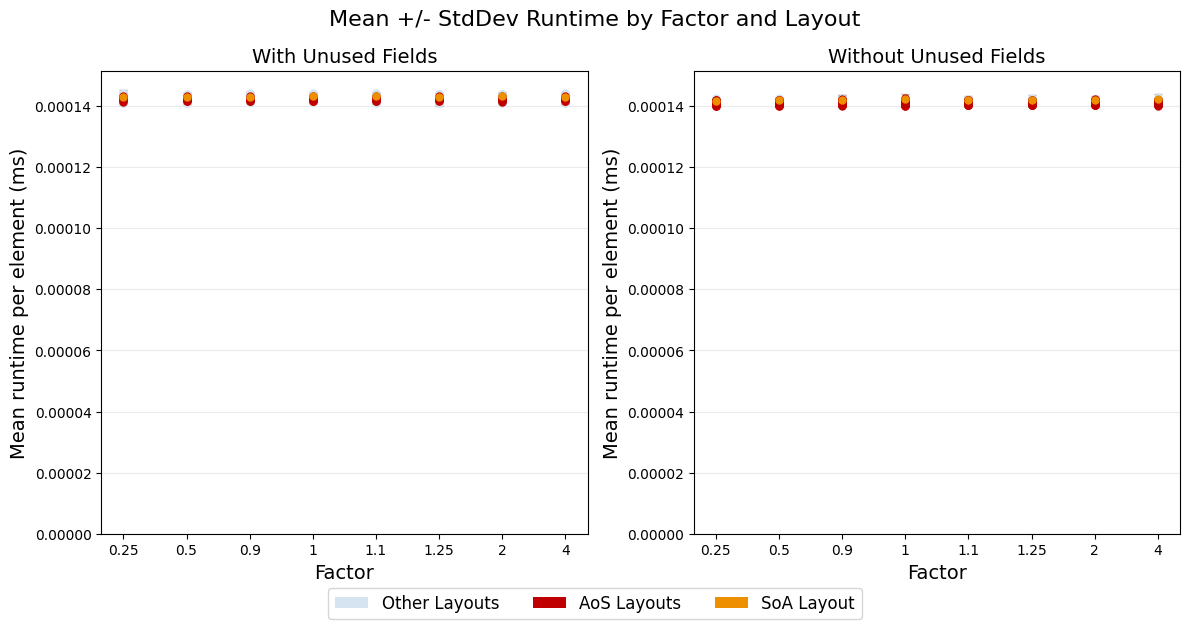

In [37]:
# Build plotting table using Google Benchmark aggregate rows paired by family_index
from matplotlib.patches import Patch
from itertools import permutations


def build_plot_df(maf_results):
    agg = maf_results[maf_results["aggregate_name"].isin(["mean", "stddev"])].copy()

    mean_rows = (
        agg[agg["aggregate_name"] == "mean"][
            ["family_index", "layout", "factor", "real_time", "problem_size"]
        ]
        .rename(columns={"real_time": "mean"})
        .copy()
    )

    std_rows = (
        agg[agg["aggregate_name"] == "stddev"][["family_index", "real_time"]]
        .rename(columns={"real_time": "stddev"})
        .copy()
    )

    plot_df = mean_rows.merge(
        std_rows,
        on="family_index",
        how="left",
        validate="one_to_one",
    )

    # Normalize by problem_size
    plot_df["normalized_mean"] = plot_df["mean"] / plot_df["problem_size"]
    # error propagation for A/B: https://en.wikipedia.org/wiki/Propagation_of_uncertainty#Example_formulae
    plot_df["normalized_stddev"] = np.abs(plot_df["normalized_mean"]) * np.sqrt(
        (plot_df["stddev"] / plot_df["mean"]) ** 2
    )

    return plot_df


def plot_maf_results(ax, maf_results, aos_layouts, soa_layout, title=""):
    plot_df = build_plot_df(maf_results)

    # Keep factor order stable and map to y positions
    factors = sorted(plot_df["factor"].unique())
    y_pos = {factor: i for i, factor in enumerate(factors)}
    plot_df["y"] = plot_df["factor"].map(y_pos)

    for layout in [
        l for l in plot_df["layout"].unique() if l not in aos_layouts and l != "1_2_3_4"
    ]:
        d = plot_df[plot_df["layout"] == layout].sort_values("y")
        ax.errorbar(
            d["y"],
            d["normalized_mean"],
            yerr=d["normalized_stddev"],
            fmt="o",
            markersize=5,
            capsize=3,
            color=other_color,
            ecolor=stddev_color,
        )

    for layout in aos_layouts:
        d = plot_df[plot_df["layout"] == layout]
        ax.errorbar(
            d["y"],
            d["normalized_mean"],
            yerr=d["normalized_stddev"],
            fmt="o",
            markersize=5,
            capsize=3,
            color=aos_color,
            ecolor=stddev_color,
        )

    d = plot_df[plot_df["layout"] == soa_layout]
    ax.errorbar(d["y"], d["normalized_mean"], yerr=d["normalized_stddev"], fmt="o", markersize=5, capsize=3, color=soa_color, ecolor=stddev_color)

    ax.set_xticks(range(len(factors)))
    ax.set_xticklabels([f"{f:g}" for f in factors])
    ax.set_ylabel(f"Mean runtime per element ({maf_results['time_unit'].iloc[0]})", fontsize=14)
    ax.set_xlabel("Factor", fontsize=14)
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(title, fontsize=14)

    return plot_df


fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Mean +/- StdDev Runtime by Factor and Layout", fontsize=16)

aos_layouts = ["".join(p) for p in permutations("0123456")]
soa_layout = "0_1_2_3_4_5_6"
plot_maf_results(axs[0], maf_results_u, aos_layouts, soa_layout, "With Unused Fields")

aos_layouts = ["".join(p) for p in permutations("0123")]
soa_layout = "0_1_2_3"
plot_maf_results(axs[1], maf_results_nu, aos_layouts, soa_layout, "Without Unused Fields")

shared_df = pd.concat([build_plot_df(maf_results_u), build_plot_df(maf_results_nu)], ignore_index=True)
ymax = shared_df["normalized_mean"].max()
pad = 0.05 * ymax if ymax > 0 else 0.01
for ax in axs:
    ax.set_ylim(0, ymax + pad)

legend_elems = [Patch(facecolor=other_color, edgecolor="none", label="Other Layouts"),
                Patch(facecolor=aos_color, edgecolor="none", label="AoS Layouts"),
                Patch(facecolor=soa_color, edgecolor="none", label="SoA Layout")
                ]
fig.legend(handles=legend_elems, loc="lower center", ncols=3, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


# Field Ordering

In [7]:
maf_kernel = "InvariantMassSequential"
for pi, ps in enumerate(zen4["problem_size"].unique()):
    df = zen4[(zen4["benchmark"] == maf_kernel) & (zen4["problem_size"] == ps)]
    maf_df = df[(df["container"] != "0123456") & (df["container"] != "0_1_2_3_4_5_6")]
    maf_mean = maf_df.groupby("container")["time"].mean().reset_index()
    time_lh_idx = np.argsort(maf_mean["time"])
    print(f"Problem size: {ps}")
    print(maf_mean["time"].min(), maf_mean["time"].max())
    print(f"{' '.join(maf_mean.iloc[time_lh_idx]['container'][:10])}  {' '.join(maf_mean.iloc[time_lh_idx]['container'][::-1][:10])}")


Problem size: 91
0.010541 0.018442300000000002
132540_6 034251_6 3164205 530124_6 452310_6 203415_6 3205641 5063241 512043_6 2105463  4350216 064_3521 31506_24 3510_264 0_125_36_4 30_15_24_6 063_521_4 0_1_4325_6 3054_1_2_6 4053_126
Problem size: 279620
39.47397 44.46221
240531_6 42301_56 04213_56 13024_65 053421_6 321450_6 02341_56 250431_6 324501_6 23140_65  3645201 02_53641 106_23_54 6430_15_2 3016_425 0_1_62_453 531402_6 10_6235_4 23405_61 503126_4
